# PD Analysis (Modular)

This notebook is a concise entry point. All heavy lifting lives in `pd_pipeline/`.


In [20]:
import sys, pathlib

PROJECT_ROOT = pathlib.Path.cwd().resolve()
if not (PROJECT_ROOT / 'pd_pipeline').exists():
    PROJECT_ROOT = next(
        (candidate for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents] if (candidate / 'pd_pipeline').exists()),
        PROJECT_ROOT,
    )
NOTEBOOK_DIR = PROJECT_ROOT / '01_pd_analysis'
DATA_DIR = PROJECT_ROOT / 'data'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from pd_pipeline import basel, capital, config, data, lasso, plots, portfolio, scenario, sensitivity


In [21]:
# Load and merge macro + GPR data
# Regression pipeline uses the interpolated monthly GDP series.
macro_frames = data.load_macro_data(
    gdp_path      = str(DATA_DIR / 'macro' / 'GDPREALGLOBAL_monthly.csv'),
    interest_path = str(DATA_DIR / 'macro' / 'intrest FRED.csv'),
    brent_path    = str(DATA_DIR / 'macro' / 'brent_oil_monthly.csv'),
    fuel_path     = str(DATA_DIR / 'macro' / 'fuel_index_monthly.csv'),
    cpi_path      = str(DATA_DIR / 'macro' / 'global_cpi_monthly.csv'),
    verbose       = False,
)

df_gpr = data.load_gpr_data(str(DATA_DIR / 'geopolitical' / 'data_gpr_Data_GPR.csv'), verbose=True)

df_merged = data.merge_macro_data(macro_frames, df_gpr)

# Covariance / correlation uses the non-interpolated quarterly GDP series.
# Other macro/GPR variables stay in levels, filtered to quarter-end months only.
df_gdp_quarterly = data.load_gdprealglobal_quarterly(str(DATA_DIR / 'macro' / 'GDPREALGLOBAL.csv'))
df_summary = (
    df_merged.drop(columns=['GDP_Growth'])
    .merge(df_gdp_quarterly, on='Date', how='inner')
)

cov_matrix, corr_matrix, mean_vector = data.summarize_macro_data(
    df_summary,
    config.ALL_PREDICTOR_COLS,
    verbose=False,
)

# Add t-1 … t-4 lags for all macro + GPR variables
df_merged = data.add_macro_lags(df_merged, config.MACRO_COLS + config.GPR_COLS, n_lags=4)
print(f"df_merged now has {df_merged.shape[1]} columns ({config.N_LAGS} lags added per variable)")


Cleaned df_gpr head:
        Date  GPR_Global
0 1985-01-01  102.173378
1 1985-02-01  117.102020
2 1985-03-01  124.778152
3 1985-04-01   87.929001
4 1985-05-01  103.262848
df_merged now has 34 columns (4 lags added per variable)


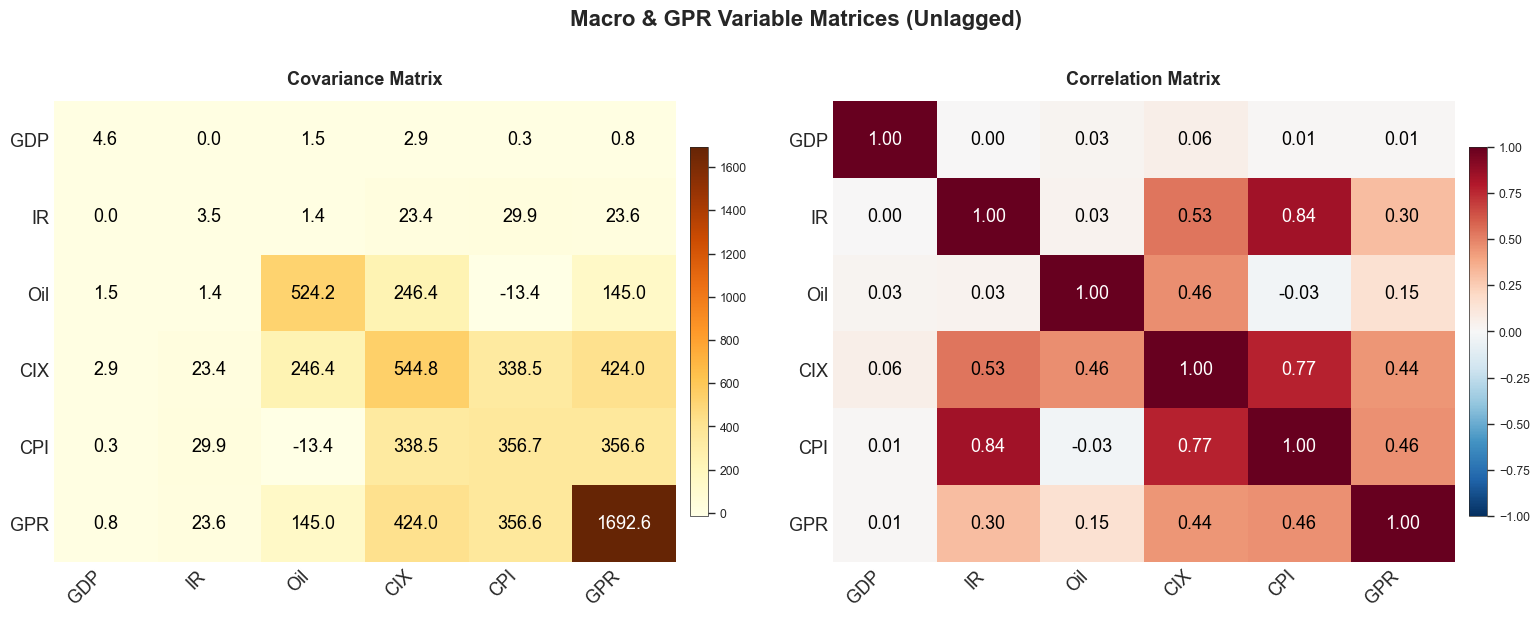

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

sns.set_theme(style='white', context='paper')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

for ax, matrix, title in zip(
    axes,
    [cov_matrix, corr_matrix],
    ['Covariance Matrix', 'Correlation Matrix'],
):
    labels = [plots._PRETTY_LABELS.get(c, c.replace('_', ' ')) for c in matrix.columns.tolist()]
    n = len(labels)
    vals = matrix.values

    vmax = 1.0 if 'Correlation' in title else None
    vmin = -1.0 if 'Correlation' in title else None
    cmap = 'RdBu_r' if 'Correlation' in title else 'YlOrBr'

    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.outline.set_linewidth(0.5)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=13)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(n):
        for j in range(n):
            v = vals[i, j]
            txt = f"{v:.2f}" if 'Correlation' in title else f"{v:.1f}"
            color = 'white' if abs(v) > (0.6 if 'Correlation' in title else 0.7 * vals.max()) else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=13, color=color)

plt.suptitle('Macro & GPR Variable Matrices (Unlagged)', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

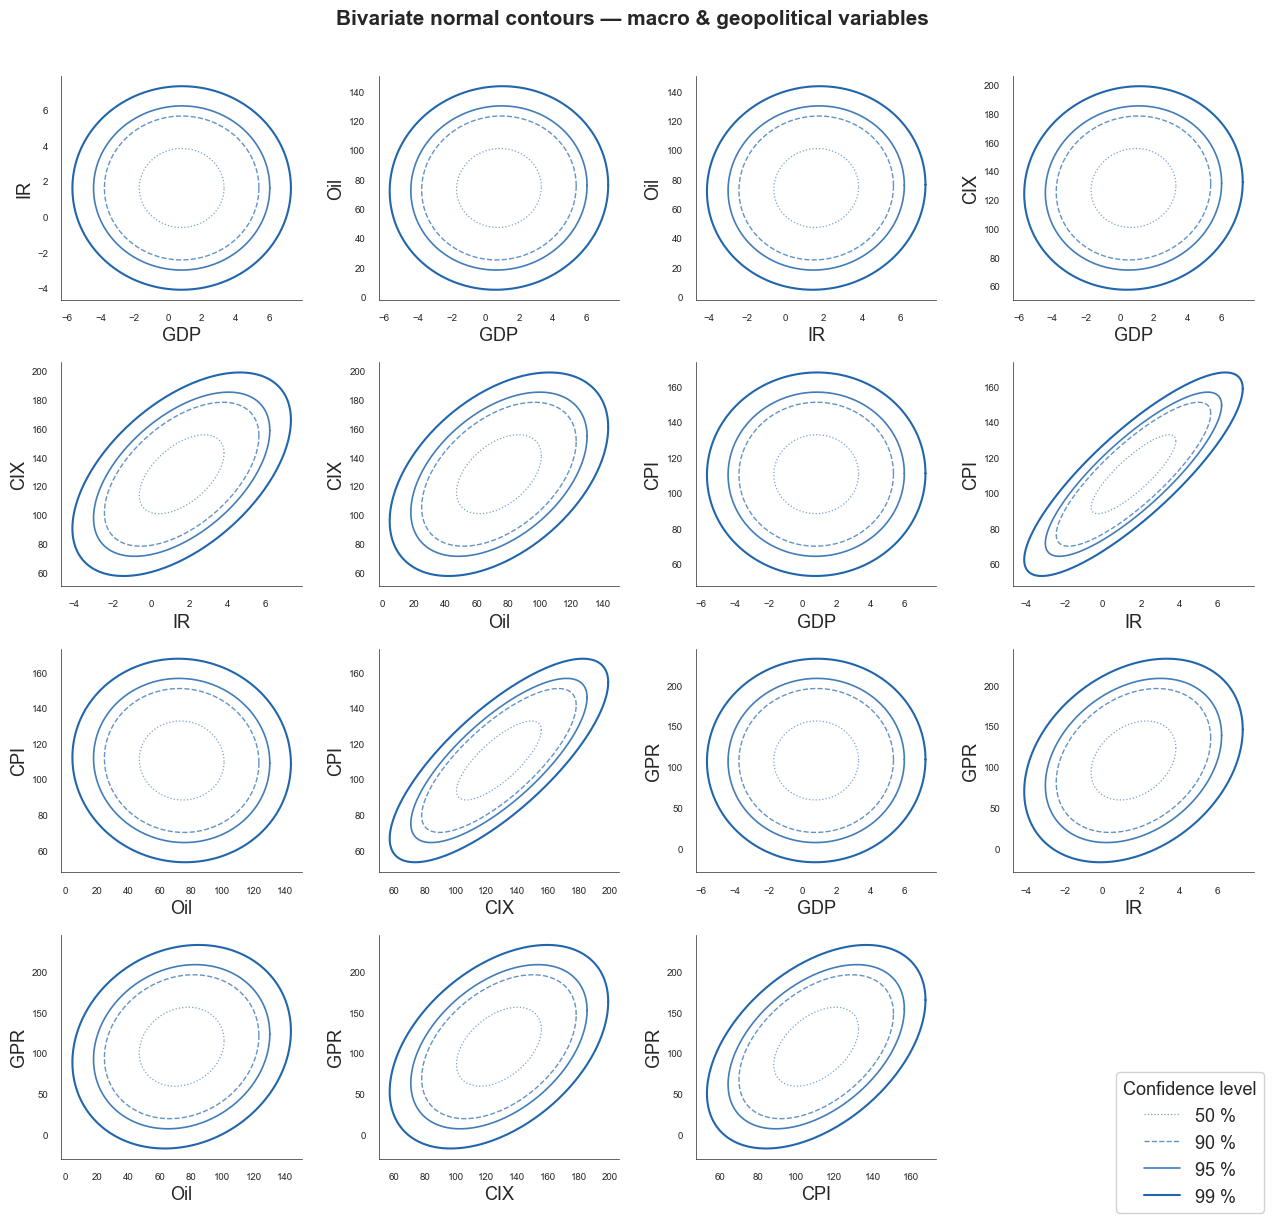

In [23]:
# Bivariate normal contour plots — all pairwise macro & geopolitical variable combinations
# Contours are derived from the covariance matrix (not historical data directly).
# Shows 50 %, 90 %, 95 %, and 99 % confidence ellipses of the fitted bivariate normal.

plots.plot_normal_contours_pairwise(
    cov_matrix=cov_matrix,
    mean_vector=mean_vector,
    cols=config.MACRO_COLS + config.GPR_COLS,
)

In [24]:
# Rebuild fitch_pds_20260301_sic_div2.csv from 20260301 Fitch Ratings Corporate.csv
# (Re-run this cell whenever the source Fitch data or sector mapping changes)
import runpy
runpy.run_path(str(PROJECT_ROOT / 'build_pd_data.py'))

# Load PDs and merge with macro data
df_pds = data.load_pds_data(str(DATA_DIR / 'PDs' / 'fitch_pds_20260301_sic_div2_dedup.csv'), verbose=False)
df_final = data.merge_pds_macro(df_pds, df_merged, verbose=False)

# Drop rows where any current or lagged predictor is missing (removes first ~12 months per series)
df_final_cleaned = data.prepare_model_data(
    df_final,
    config.ALL_PREDICTOR_COLS_WITH_LAGS,
    sector_col=config.SECTOR_COL,
    verbose=False,
)

# Remove excluded sectors 
# These are structurally different from standard corporate obligors and would
# distort the macro-sensitivity estimates if kept in.
before_excl = len(df_final_cleaned)
df_final_cleaned = df_final_cleaned[
    ~df_final_cleaned[config.SECTOR_COL].isin(config.EXCLUDED_SECTORS)
].copy()
removed = before_excl - len(df_final_cleaned)
print(
    f"\nExcluded sectors {config.EXCLUDED_SECTORS}:\n"
    f"  Removed {removed:,} rows  →  {len(df_final_cleaned):,} rows remaining"
)
print("Remaining sectors:", sorted(df_final_cleaned[config.SECTOR_COL].unique()))


Loading IsinCusiptoSic.csv …
  ISIN lookup : 11,211 entries
  CUSIP lookup: 22,668 entries

Loading Fitch Ratings Corporate file …
  Raw rows: 119,920
  After long-term filter: 115,840
  After WD/NR filter: 88,637
  Rows with SIC found: 68,638
  Unique companies with SIC: 3,834
  Dropped 16,353 rows (obligors with no SIC)
  Remaining rows: 72,284
  Dropped 272 rows (unmapped long-term ratings)

✓ Saved 72,012 rows to /Users/gustavjerresand/RST2.0-Modellen/data/PDs/fitch_long_term_pds_with_sic.csv
✓ Saved 19,727 rows to /Users/gustavjerresand/RST2.0-Modellen/data/PDs/fitch_pds_20260301_sic_div2_dedup.csv

Sector distribution:
Sector
Finance, Insurance & Real Estate        4813
Utilities                               3234
Light Manufacturing                     2170
Heavy Manufacturing                     1995
Mining & Construction                   1617
Communications                          1518
Services                                1364
Wholesale & Retail Trade                1296


In [25]:
# ── df_final_cleaned verification ────────────────────────────────────────────
print("=" * 60)
print("df_final_cleaned  –  DATA VERIFICATION")
print("=" * 60)

print(f"\nShape : {df_final_cleaned.shape[0]:,} rows × {df_final_cleaned.shape[1]} columns")
print(f"Date range : {df_final_cleaned['Date'].min().date()}  →  {df_final_cleaned['Date'].max().date()}")
print(f"Companies  : {df_final_cleaned['Company_number'].nunique():,} unique")

if 'Sector' in df_final_cleaned.columns:
    print(f"\nSector distribution:")
    print(df_final_cleaned['Sector'].value_counts().to_string())

print("\nMissing values per column:")
missing = df_final_cleaned.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if not missing.empty else "  None")

macro_cols = ['GDP_Growth', 'Interest_Rate', 'Brent_Oil', 'CPI',
              'GPR_Global']
available_macro = [c for c in macro_cols if c in df_final_cleaned.columns]
print(f"\nMacro summary ({', '.join(available_macro)}):")
print(df_final_cleaned[available_macro].describe().round(3).to_string())

print(f"\nPD (12_month) summary:")
print(df_final_cleaned['12_month'].describe().round(6).to_string())

print(f"\nFirst 5 rows:")
display_cols = ['Date', 'Company_number'] + (['Sector'] if 'Sector' in df_final_cleaned.columns else []) + ['12_month'] + available_macro[:3]
print(df_final_cleaned[display_cols].head(5).to_string(index=False))

df_final_cleaned  –  DATA VERIFICATION

Shape : 18,135 rows × 38 columns
Date range : 2012-08-01  →  2025-02-01
Companies  : 3,647 unique

Sector distribution:
Sector
Finance, Insurance & Real Estate        4525
Utilities                               2931
Light Manufacturing                     1973
Heavy Manufacturing                     1815
Mining & Construction                   1499
Communications                          1383
Services                                1271
Wholesale & Retail Trade                1168
Transportation                           882
Health, Legal & Educational Services     415
Public Administration                    273

Missing values per column:
  None

Macro summary (GDP_Growth, Interest_Rate, Brent_Oil, CPI, GPR_Global):
       GDP_Growth  Interest_Rate  Brent_Oil        CPI  GPR_Global
count   18135.000      18135.000  18135.000  18135.000   18135.000
mean        0.696          1.472     72.687    109.437     103.277
std         2.124          1.8

In [26]:
# Normalise macro + GPR variables (z-score) before any model sees them.
# All OLS, Elastic-Net, and subsequent notebooks read normalised inputs.
# `macro_scaler` stores (mean, std) per base variable for back-transformation.
df_final_cleaned, macro_scaler = data.normalize_macro_columns(
    df_final_cleaned,
    cols=config.ALL_PREDICTOR_COLS,   # base variables only; lags auto-detected
    verbose=True,
)

Macro columns normalised (z-score, pooled across all rows):
  GDP_Growth                         : mean=    0.696,  std=   2.124
  Interest_Rate                      : mean=    1.472,  std=   1.827
  Brent_Oil                          : mean=   72.687,  std=  23.076
  Fuel_Index                         : mean=  125.911,  std=  21.574
  CPI                                : mean=  109.437,  std=  16.717
  GPR_Global                         : mean=  103.277,  std=  35.156


In [27]:
# OLS sensitivity analysis (includes current + lagged macro/GPR variables)

df_sensitivities = sensitivity.run_sensitivity_analysis(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=False,
)

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
print(df_sensitivities)



SENSITIVITY ANALYSIS RESULTS
                                  Sector PD_Horizon  Intercept  \
0                  Mining & Construction   12_month   0.518497   
1                         Transportation   12_month   0.145686   
2                         Communications   12_month   0.584227   
3       Finance, Insurance & Real Estate   12_month   0.123568   
4                              Utilities   12_month   0.079162   
5                    Heavy Manufacturing   12_month   0.067884   
6                    Light Manufacturing   12_month  -0.027226   
7                  Public Administration   12_month  -0.002403   
8               Wholesale & Retail Trade   12_month   0.283390   
9                               Services   12_month  -0.073867   
10  Health, Legal & Educational Services   12_month   0.153833   

    N_observations  N_predictors  R_squared  R_squared_adj           AIC  \
0             1499            30   0.059972       0.040762   5274.193882   
1              882       

In [28]:

sensitivity.print_sensitivity_tables(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)

sensitivity.print_confidence_interval_summary(df_sensitivities, config.ALL_GPR_COLS)

# Uncomment for a full per-sector printout (very verbose)
# sensitivity.print_sensitivity_details(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)


MACRO SENSITIVITIES (β) - Impact of macroeconomic variables on PD
                                  Sector PD_Horizon  N_observations  \
0                  Mining & Construction   12_month            1499   
1                         Transportation   12_month             882   
2                         Communications   12_month            1383   
3       Finance, Insurance & Real Estate   12_month            4525   
4                              Utilities   12_month            2931   
5                    Heavy Manufacturing   12_month            1815   
6                    Light Manufacturing   12_month            1973   
7                  Public Administration   12_month             273   
8               Wholesale & Retail Trade   12_month            1168   
9                               Services   12_month            1271   
10  Health, Legal & Educational Services   12_month             415   

    N_predictors  R_squared  R_squared_adj           AIC           BIC  \
0      

### Sensitivity analysis — reporting fit and coefficients



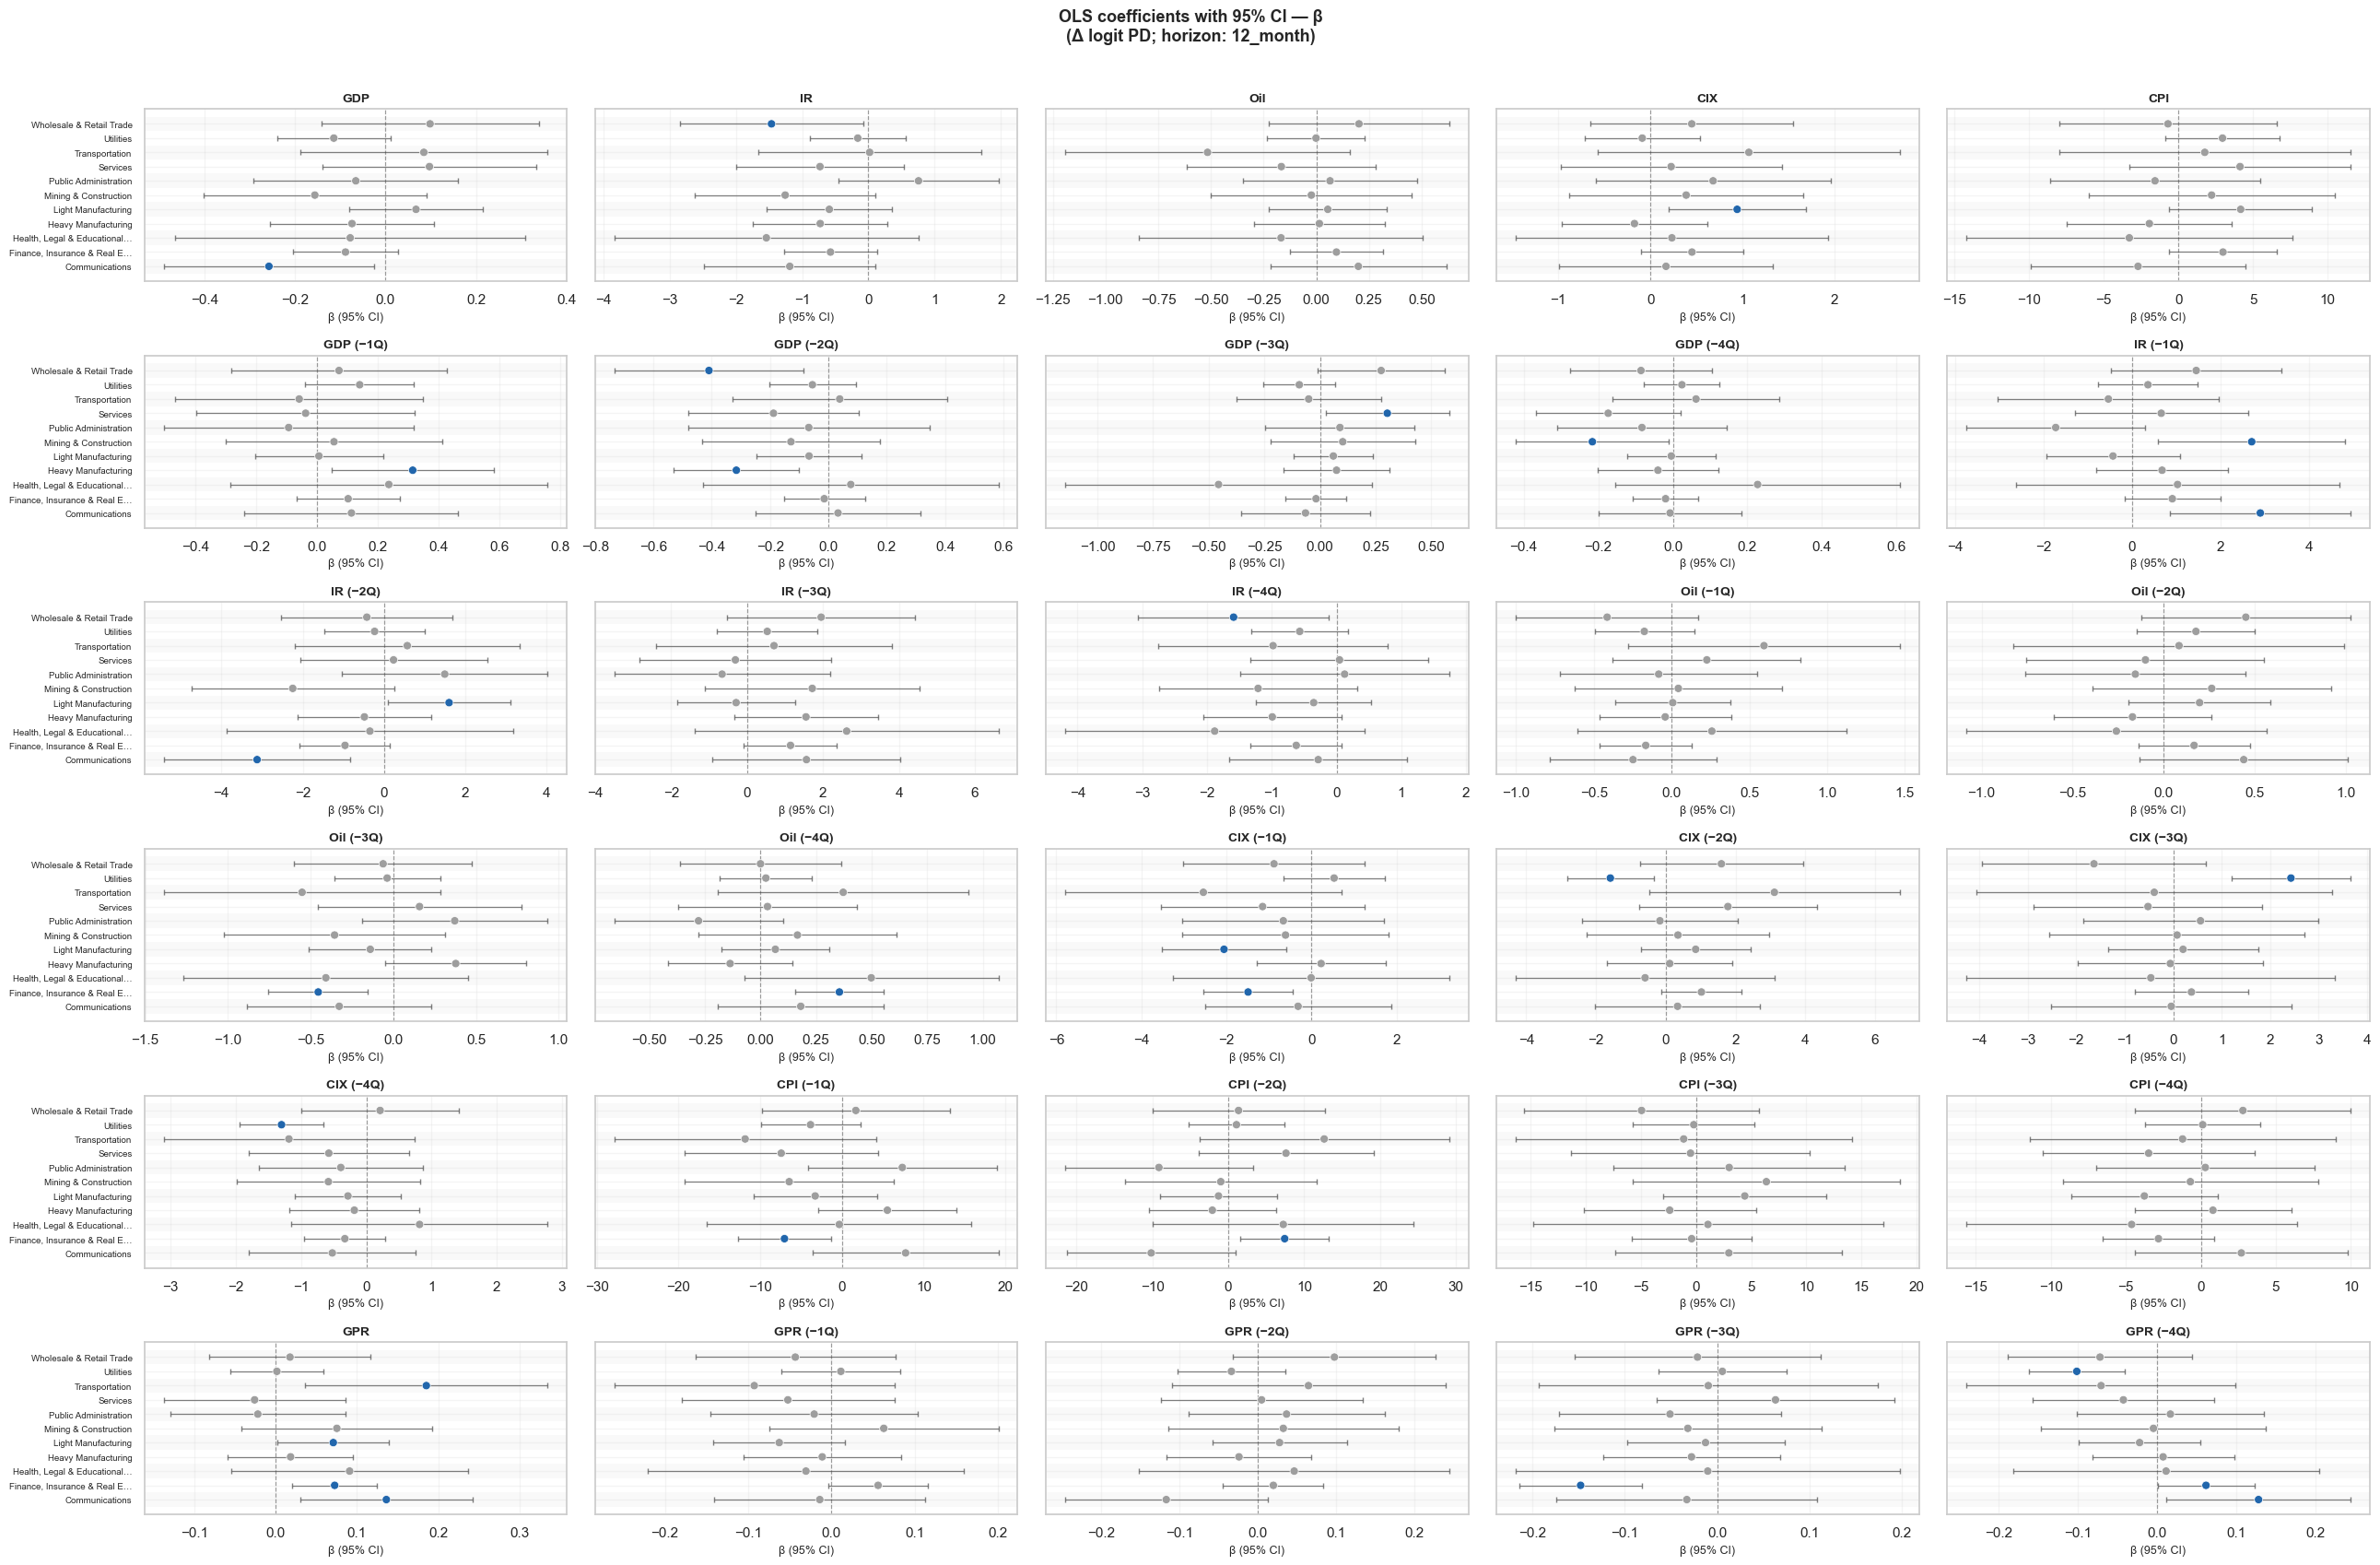

In [29]:
_pd_h = config.PD_MATURITY_COLS[0]


# OLS forests — every regressor in the full lagged specification (macro + GPR combined)
plots.plot_sensitivity_forests_all_predictors(
    df_sensitivities,
    config.ALL_MACRO_COLS,
    config.ALL_GPR_COLS,
    pd_horizon=_pd_h,
)

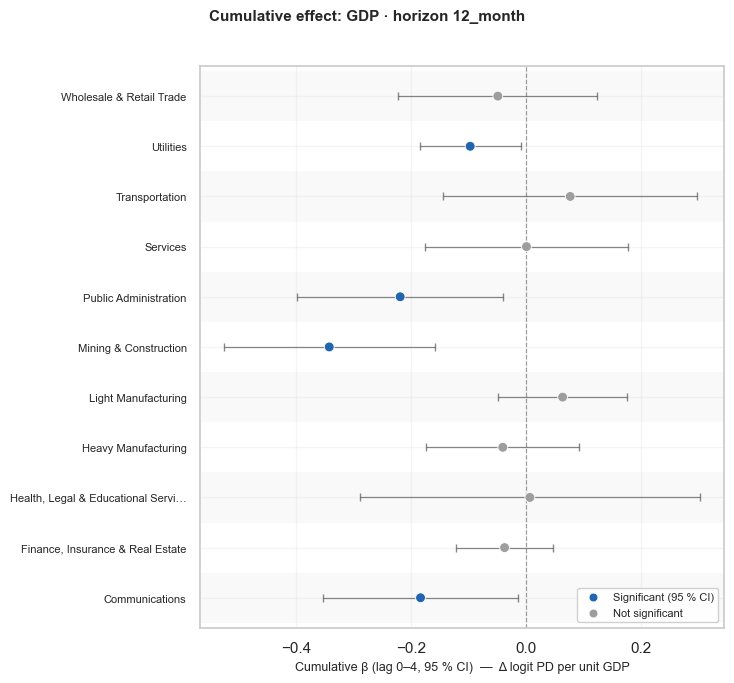

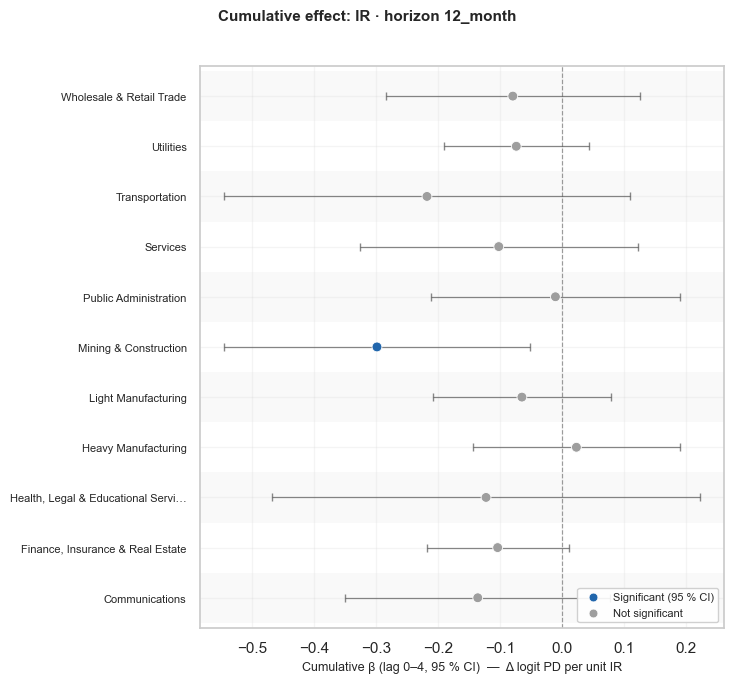

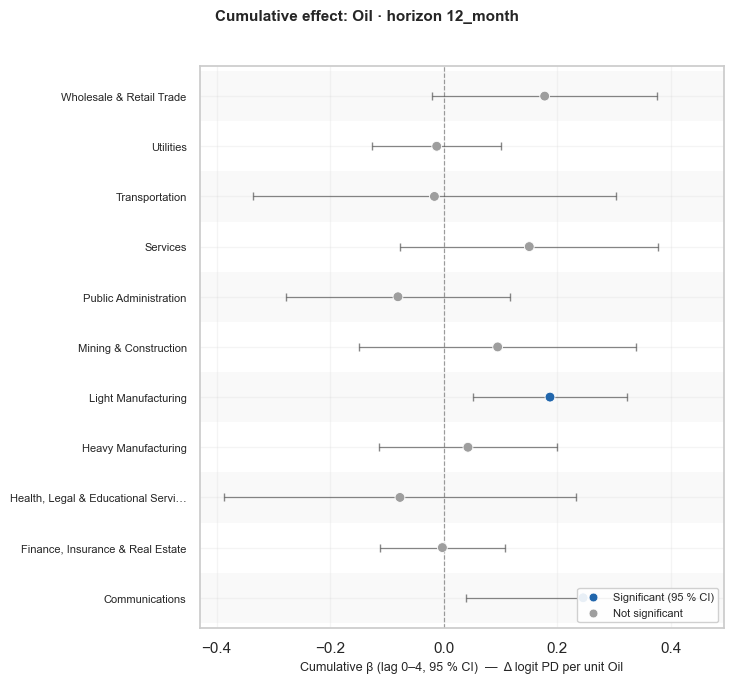

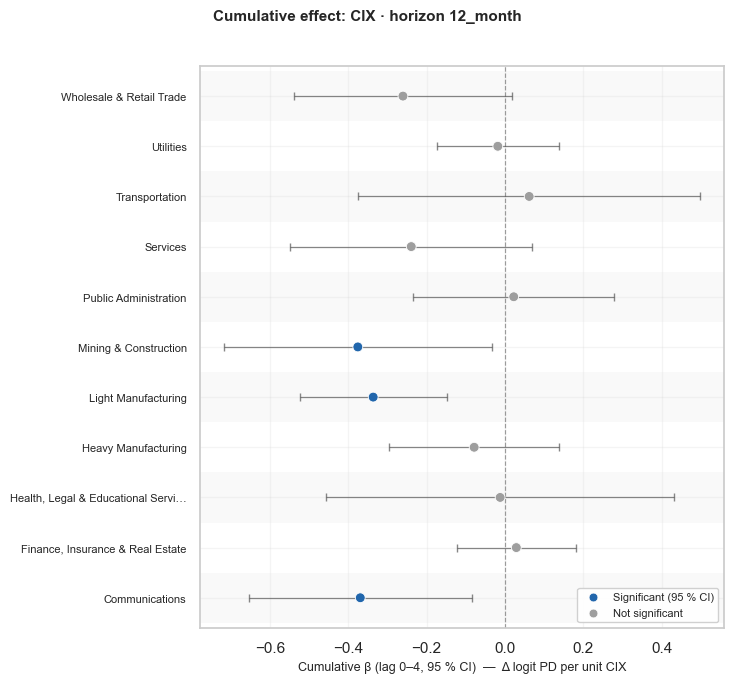

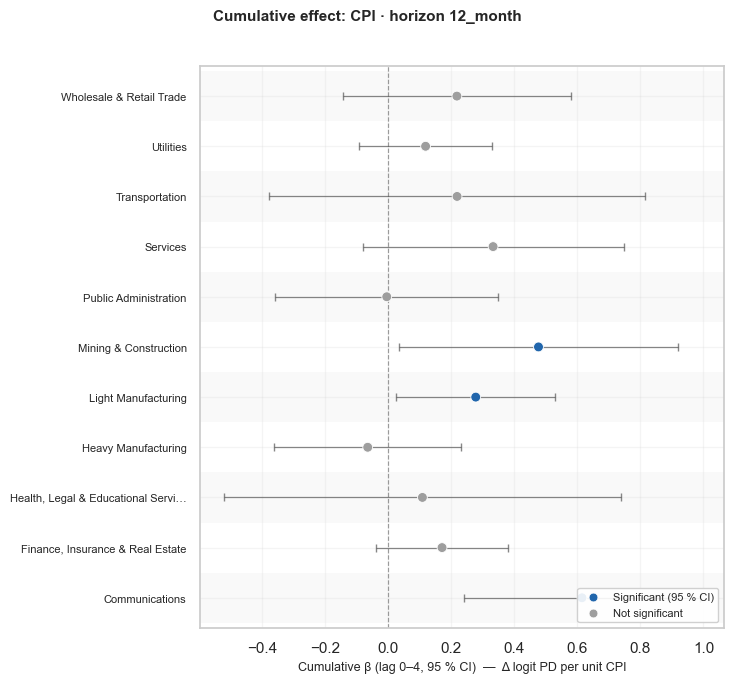

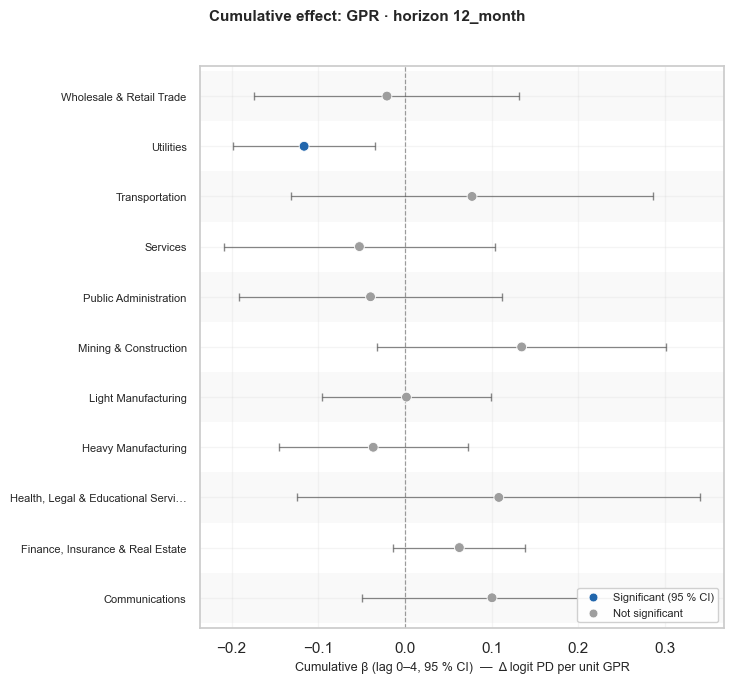

In [30]:
# Cumulative (summed) OLS coefficients — one thesis figure per variable
# β_total = β_lag0 + β_lag1 + β_lag2 + β_lag3 + β_lag4  (same for δ / GPR)
# 95 % CI propagated in quadrature (independent-lags approximation)

_pd_h = config.PD_MATURITY_COLS[0]

plots.plot_cumulative_coefficient_forest(
    df_sensitivities,
    base_cols=config.MACRO_COLS,
    all_cols=config.ALL_MACRO_COLS,
    kind='macro',
    pd_horizon=_pd_h,
)

plots.plot_cumulative_coefficient_forest(
    df_sensitivities,
    base_cols=config.GPR_COLS,
    all_cols=config.ALL_GPR_COLS,
    kind='gpr',
    pd_horizon=_pd_h,
)

In [31]:
# Elastic-Net feature selection (ElasticNetCV over alpha × l1_ratio grid)
df_lasso, lasso_selected_features = lasso.run_lasso_feature_selection(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=False,
)

feature_freq_df = lasso.print_lasso_summary(df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
comparison_full = lasso.compare_ols_lasso(df_sensitivities, df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
lasso.print_feature_recommendations(feature_freq_df, comparison_full)

# Bootstrap stability (B=200 per sector — takes a few minutes)
df_lasso = lasso.run_bootstrap_stability(
    df_final_cleaned, df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    n_bootstrap=200,
    verbose=False,
)

# Regularization paths (used for the path plot below)
path_data = lasso.compute_regularization_paths(
    df_final_cleaned, df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=False,
)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was de


ELASTIC-NET RESULTS SUMMARY
                                  Sector PD_Horizon  N_observations  \
0                  Mining & Construction   12_month            1499   
1                         Transportation   12_month             882   
2                         Communications   12_month            1383   
3       Finance, Insurance & Real Estate   12_month            4525   
4                              Utilities   12_month            2931   
5                    Heavy Manufacturing   12_month            1815   
6                    Light Manufacturing   12_month            1973   
7                  Public Administration   12_month             273   
8               Wholesale & Retail Trade   12_month            1168   
9                               Services   12_month            1271   
10  Health, Legal & Educational Services   12_month             415   

    Optimal_Alpha  Optimal_L1_Ratio  R_squared  R_squared_adj  R_squared_cv  \
0        0.108445              0.95   0

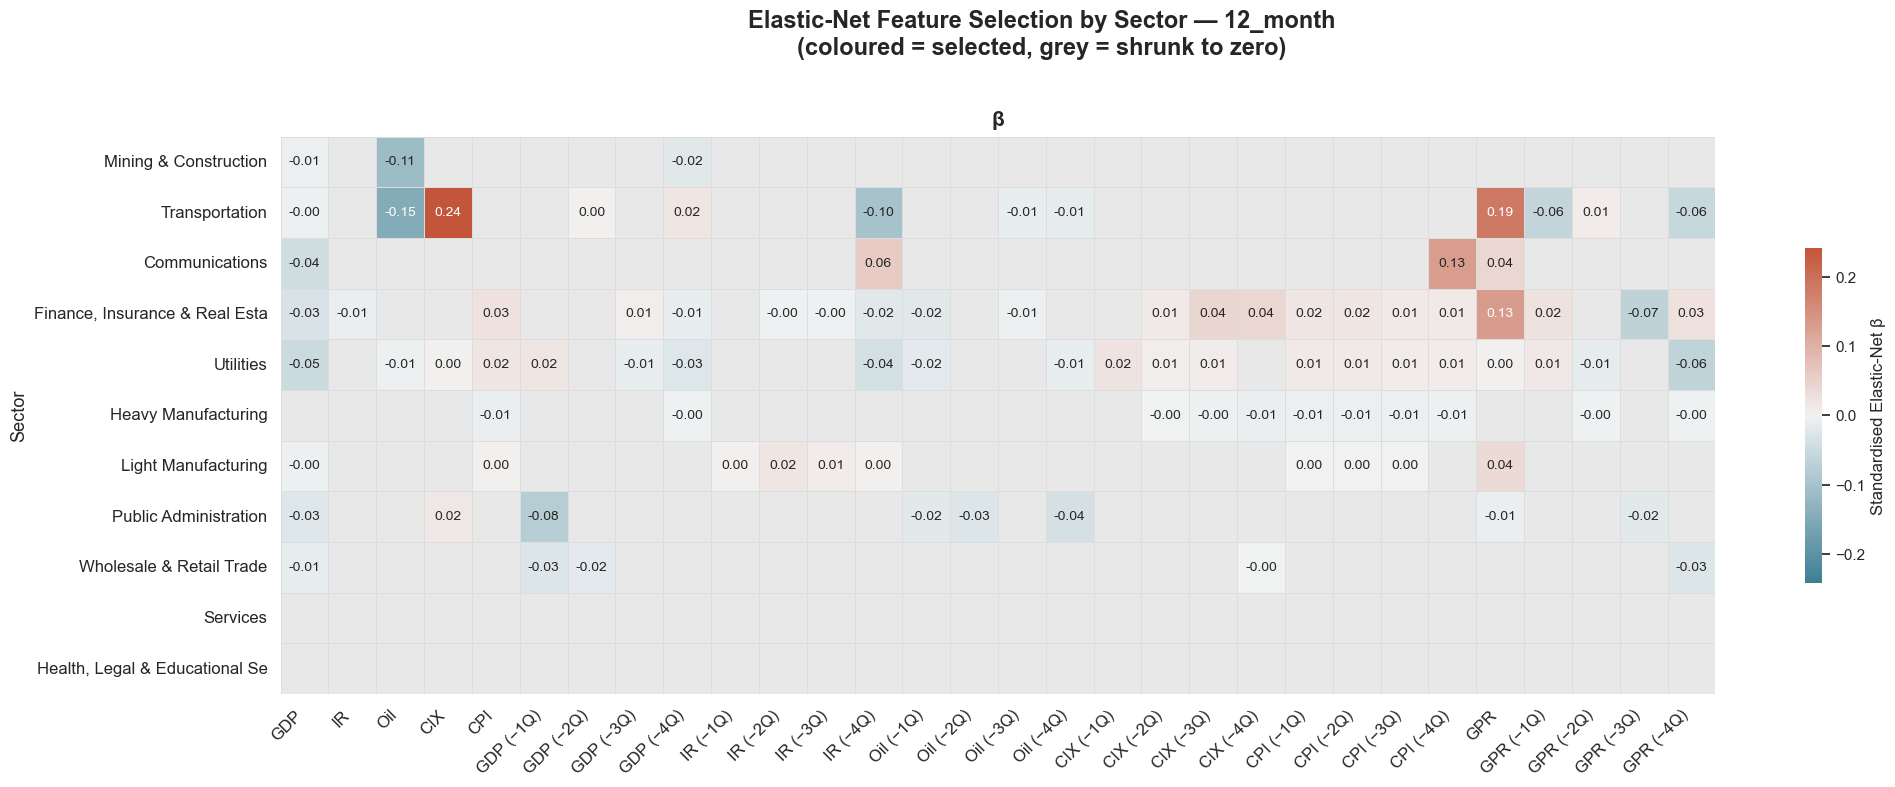

In [32]:

plots.plot_lasso_beta_heatmap(
    df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    pd_horizon=config.PD_MATURITY_COLS[0],
)

### Model Selection: Which Sensitivity Specification to Use in the Optimisation?




In [33]:

# ── Three-model comparison: M1 (full-lag OLS) | M2 (cumulative OLS) | M3 (EN) ─
#
# M1: OLS with current + 4 lags as separate predictors  → 30 predictors
# M2: OLS where each variable is replaced by its cumulative sum → 6 predictors
# M3: Elastic-Net on the same 30-predictor set (CV-regularised)
#
# We compute 5-fold CV R² for all three so the comparison is on equal footing.

import statsmodels.api as sm
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

_CV_FOLDS = 5
_pd_h = config.PD_MATURITY_COLS[0]


def _build_cumulative_X(df, macro_cols, gpr_cols):
    """Replace each base variable with its cumulative sum across lags.

    For each base variable (e.g. GDP_Growth), sum the contemporaneous value
    and all lagged versions present in the DataFrame into a single column.
    Returns a DataFrame with one column per base variable.
    """
    base_macro = config.MACRO_COLS   # contemporaneous names only
    base_gpr   = config.GPR_COLS

    cumul = {}
    for base in base_macro:
        lag_cols = [c for c in macro_cols if c == base or c.startswith(f'{base}_lag')]
        cumul[f'{base}_cumul'] = df[lag_cols].sum(axis=1)
    for base in base_gpr:
        lag_cols = [c for c in gpr_cols if c == base or c.startswith(f'{base}_lag')]
        cumul[f'{base}_cumul'] = df[lag_cols].sum(axis=1)
    return pd.DataFrame(cumul, index=df.index)


def _fit_sector_ols(y, X_raw, n_preds=None):
    """OLS fit; returns (r2, r2_adj, aic, bic) or Nones on failure."""
    X = sm.add_constant(X_raw)
    try:
        m = sm.OLS(y, X).fit()
        k = n_preds if n_preds is not None else (X.shape[1] - 1)
        n = len(y)
        r2_adj = 1 - (1 - m.rsquared) * (n - 1) / (n - k - 1) if n > k + 1 else float('nan')
        return m.rsquared, r2_adj, m.aic, m.bic
    except Exception:
        return float('nan'), float('nan'), float('nan'), float('nan')


def _cv_r2(X_raw, y, estimator, cv=5):
    """5-fold CV R² on StandardScaler-transformed X."""
    X_sc = StandardScaler().fit_transform(X_raw)
    scores = cross_val_score(estimator, X_sc, y, cv=cv, scoring='r2')
    return float(scores.mean())


def _cv_rmse(X_raw, y, estimator, cv=5):
    """5-fold CV RMSE on StandardScaler-transformed X."""
    X_sc = StandardScaler().fit_transform(X_raw)
    scores = cross_val_score(estimator, X_sc, y, cv=cv, scoring='neg_root_mean_squared_error')
    return float(-scores.mean())


print("Fitting M2 (cumulative OLS) and computing CV R² for all three models …")

m1_rows, m2_rows = [], []

for sector in df_final_cleaned[config.SECTOR_COL].unique():
    sdf = df_final_cleaned[df_final_cleaned[config.SECTOR_COL] == sector].copy()
    sdf['delta_logit'] = (
        sensitivity.calculate_logit(sdf[_pd_h])
        - sensitivity.calculate_logit(sdf[config.PDZERO_COL])
    )
    y_full = sdf['delta_logit']

    # ── M1 predictors (30 columns) ────────────────────────────────────────────
    X1 = pd.concat([sdf[config.ALL_MACRO_COLS], sdf[config.ALL_GPR_COLS]], axis=1)
    ok1 = ~(y_full.isna() | X1.isna().any(axis=1))
    y1, X1 = y_full[ok1], X1[ok1]

    # ── M2 predictors (6 cumulative columns) ─────────────────────────────────
    X2 = _build_cumulative_X(sdf, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
    ok2 = ~(y_full.isna() | X2.isna().any(axis=1))
    y2, X2 = y_full[ok2], X2[ok2]

    if len(y1) >= 20:
        r2_1, r2adj_1, aic_1, bic_1 = _fit_sector_ols(y1, X1, n_preds=X1.shape[1])
        cv_1    = _cv_r2(X1.values, y1.values, LinearRegression(), cv=_CV_FOLDS)
        rmse_1  = _cv_rmse(X1.values, y1.values, LinearRegression(), cv=_CV_FOLDS)
        m1_rows.append({'Sector': sector, 'M1_R2': r2_1, 'M1_R2adj': r2adj_1,
                         'M1_AIC': aic_1, 'M1_BIC': bic_1, 'M1_R2cv': cv_1,
                         'M1_RMSEcv': rmse_1,
                         'M1_N_pred': X1.shape[1], 'N_obs': len(y1)})

    if len(y2) >= 20:
        r2_2, r2adj_2, aic_2, bic_2 = _fit_sector_ols(y2, X2, n_preds=X2.shape[1])
        cv_2    = _cv_r2(X2.values, y2.values, LinearRegression(), cv=_CV_FOLDS)
        rmse_2  = _cv_rmse(X2.values, y2.values, LinearRegression(), cv=_CV_FOLDS)
        m2_rows.append({'Sector': sector, 'M2_R2': r2_2, 'M2_R2adj': r2adj_2,
                         'M2_AIC': aic_2, 'M2_BIC': bic_2, 'M2_R2cv': cv_2,
                         'M2_RMSEcv': rmse_2,
                         'M2_N_pred': X2.shape[1]})

df_m1  = pd.DataFrame(m1_rows)
df_m2  = pd.DataFrame(m2_rows)

# M3: pull from existing df_lasso (already has EN CV R²)
df_m3 = (
    df_lasso[df_lasso['PD_Horizon'] == _pd_h]
    [['Sector', 'R_squared', 'R_squared_adj', 'R_squared_cv', 'RMSE_cv', 'N_features_selected']]
    .copy()
    .rename(columns={'R_squared': 'M3_R2', 'R_squared_adj': 'M3_R2adj',
                     'R_squared_cv': 'M3_R2cv', 'RMSE_cv': 'M3_RMSEcv',
                     'N_features_selected': 'M3_N_feat'})
)

comp = df_m1.merge(df_m2, on='Sector').merge(df_m3, on='Sector', how='left')

# ── Print comparison table ────────────────────────────────────────────────────
_fmt3 = lambda x: f'{x:.3f}' if pd.notna(x) else '—'
_fmt1 = lambda x: f'{x:.1f}' if pd.notna(x) else '—'

tbl = comp[['Sector', 'N_obs',
            'M1_R2adj', 'M1_R2cv',
            'M2_R2adj', 'M2_R2cv',
            'M3_R2adj', 'M3_R2cv', 'M3_N_feat']].copy()
tbl = tbl.rename(columns={
    'N_obs':      'N',
    'M1_R2adj': 'M1 Adj R²', 'M1_R2cv': 'M1 CV R²',
    'M2_R2adj': 'M2 Adj R²', 'M2_R2cv': 'M2 CV R²',
    'M3_R2adj': 'M3 Adj R²', 'M3_R2cv': 'M3 CV R²', 'M3_N_feat': 'M3 preds',
}).set_index('Sector')
tbl['N'] = tbl['N'].astype(int)
tbl['M3 preds'] = pd.array(tbl['M3 preds'], dtype='Int64')
for c in ['M1 Adj R²', 'M1 CV R²',
          'M2 Adj R²', 'M2 CV R²',
          'M3 Adj R²', 'M3 CV R²']:
    tbl[c] = tbl[c].map(_fmt3)

print(f"\nModel Comparison — PD Horizon: {_pd_h}")
print(f"  M1 = Full-lag OLS (30 preds)   M2 = Cumulative OLS (6 preds)   M3 = Elastic-Net (CV-selected preds)")
print("=" * 90)
print(tbl.to_string())
print("=" * 90)
print("\nCV R² (5-fold): negative values indicate worse-than-mean prediction.")


Fitting M2 (cumulative OLS) and computing CV R² for all three models …

Model Comparison — PD Horizon: 12_month
  M1 = Full-lag OLS (30 preds)   M2 = Cumulative OLS (6 preds)   M3 = Elastic-Net (CV-selected preds)
                                         N M1 Adj R² M1 CV R² M2 Adj R² M2 CV R² M3 Adj R² M3 CV R²  M3 preds
Sector                                                                                                       
Mining & Construction                 1499     0.041   -0.162     0.035   -0.143     0.020   -0.100         3
Transportation                         882     0.035   -0.269     0.022   -0.245     0.033   -0.236        12
Communications                        1383     0.068   -0.094     0.052   -0.050     0.051   -0.023         4
Finance, Insurance & Real Estate      4525     0.051   -0.002     0.033   -0.009     0.043    0.002        21
Utilities                             2931     0.014   -0.129     0.005   -0.102     0.007   -0.098        21
Heavy Manufactur

In [34]:

# ── Scorecard ─────────────────────────────────────────────────────────────────
print()
print("=" * 80)
print("MODEL SELECTION SCORECARD")
print("=" * 80)
print("  Metrics:")
print("  · Plain R²     — rises with every added predictor; NOT comparable across models")
print("  · Adj R²       — penalises for extra parameters; fair in-sample comparison (higher = better)")
print("  · CV R²        — 5-fold out-of-sample R²; primary selection criterion (higher = better)")
print("  · CV RMSE      — 5-fold out-of-sample RMSE; lower = better; same scale as delta_logit")
print("  Selection rule: HIGHEST CV R²  (or equivalently LOWEST CV RMSE).")
print("-" * 80)
for label, r2_col, cv_col, rmse_col, n_col, n_val in [
    ('M1  Full-lag OLS   (30 preds)', 'M1_R2adj', 'M1_R2cv', 'M1_RMSEcv', 'M1_N_pred', 30),
    ('M2  Cumulative OLS  (6 preds)', 'M2_R2adj', 'M2_R2cv', 'M2_RMSEcv', 'M2_N_pred', 6),
    ('M3  Elastic-Net (CV preds)',    'M3_R2adj', 'M3_R2cv', 'M3_RMSEcv', 'M3_N_feat', None),
]:
    r2   = comp[r2_col].mean()
    cv   = comp[cv_col].mean()
    rmse = comp[rmse_col].mean()
    np_  = comp[n_col].mean() if n_val is None else n_val
    print(f"  {label:38s}  Adj R²={r2:.3f}  CV R²={cv:.3f}  CV RMSE={rmse:.4f}  overfit gap={r2-cv:.3f}  avg preds={np_:.1f}")

print()
m2_beats_m1 = (comp['M2_R2cv'] > comp['M1_R2cv']).sum()
m3_beats_m1 = (comp['M3_R2cv'] > comp['M1_R2cv']).sum()
m3_beats_m2 = (comp['M3_R2cv'] > comp['M2_R2cv']).sum()
n = len(comp)
print(f"  CV R²: M2 > M1 in {m2_beats_m1}/{n} sectors   |   M3 > M1 in {m3_beats_m1}/{n} sectors   |   M3 > M2 in {m3_beats_m2}/{n} sectors")
print()
print("  Thesis recommendation:")
print("  - M1 (full-lag OLS) has the highest in-sample Adj R² but the largest overfit gap.")
print("  - M2 (cumulative OLS) is more parsimonious and directly yields the total-effect")
print("    coefficient needed for a level-shift stress scenario (6 predictors, lower AIC).")
print("  - M3 (Elastic-Net) provides the best generalisation: highest CV R² and lowest")
print("    overfit gap, with data-driven feature selection from the full lag set.")
print("  - Model selection criterion: highest CV R² (higher = better fit on unseen data).")
print("  - Preferred for optimisation: M3 coefficients (or M2 where EN selects zero features).")
print("=" * 80)



MODEL SELECTION SCORECARD
  Metrics:
  · Plain R²     — rises with every added predictor; NOT comparable across models
  · Adj R²       — penalises for extra parameters; fair in-sample comparison (higher = better)
  · CV R²        — 5-fold out-of-sample R²; primary selection criterion (higher = better)
  · CV RMSE      — 5-fold out-of-sample RMSE; lower = better; same scale as delta_logit
  Selection rule: HIGHEST CV R²  (or equivalently LOWEST CV RMSE).
--------------------------------------------------------------------------------
  M1  Full-lag OLS   (30 preds)           Adj R²=0.027  CV R²=-0.186  CV RMSE=1.0613  overfit gap=0.213  avg preds=30.0
  M2  Cumulative OLS  (6 preds)           Adj R²=0.022  CV R²=-0.129  CV RMSE=1.0462  overfit gap=0.151  avg preds=6.0
  M3  Elastic-Net (CV preds)              Adj R²=0.021  CV R²=-0.102  CV RMSE=1.0375  overfit gap=0.124  avg preds=8.6

  CV R²: M2 > M1 in 10/11 sectors   |   M3 > M1 in 11/11 sectors   |   M3 > M2 in 10/11 sectors

  T

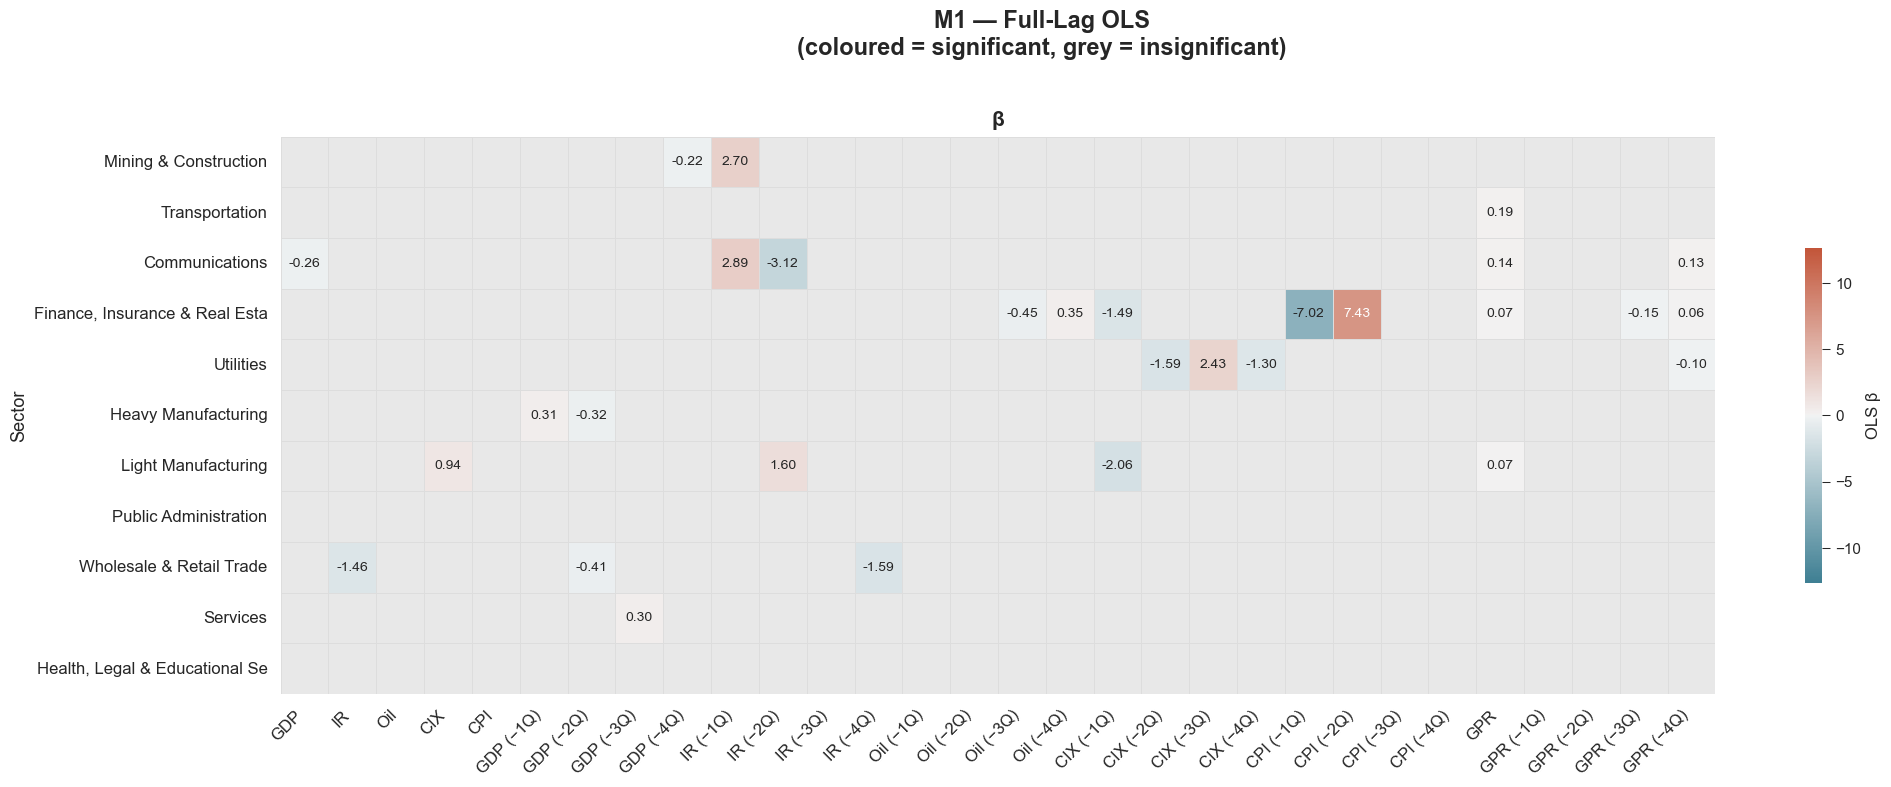

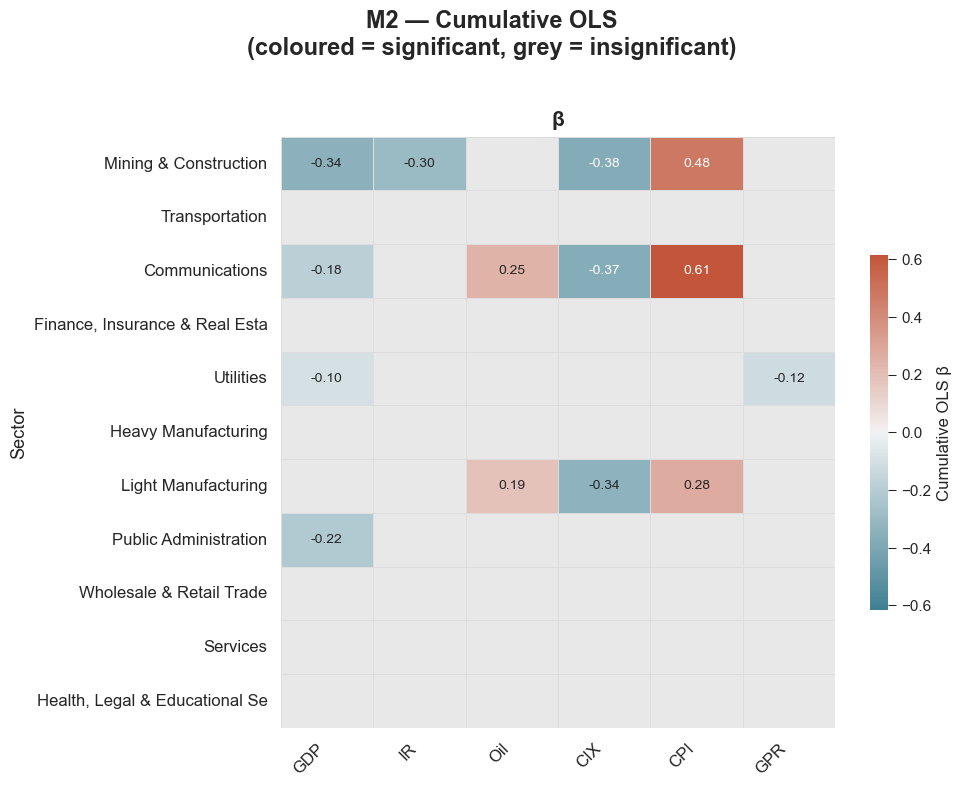

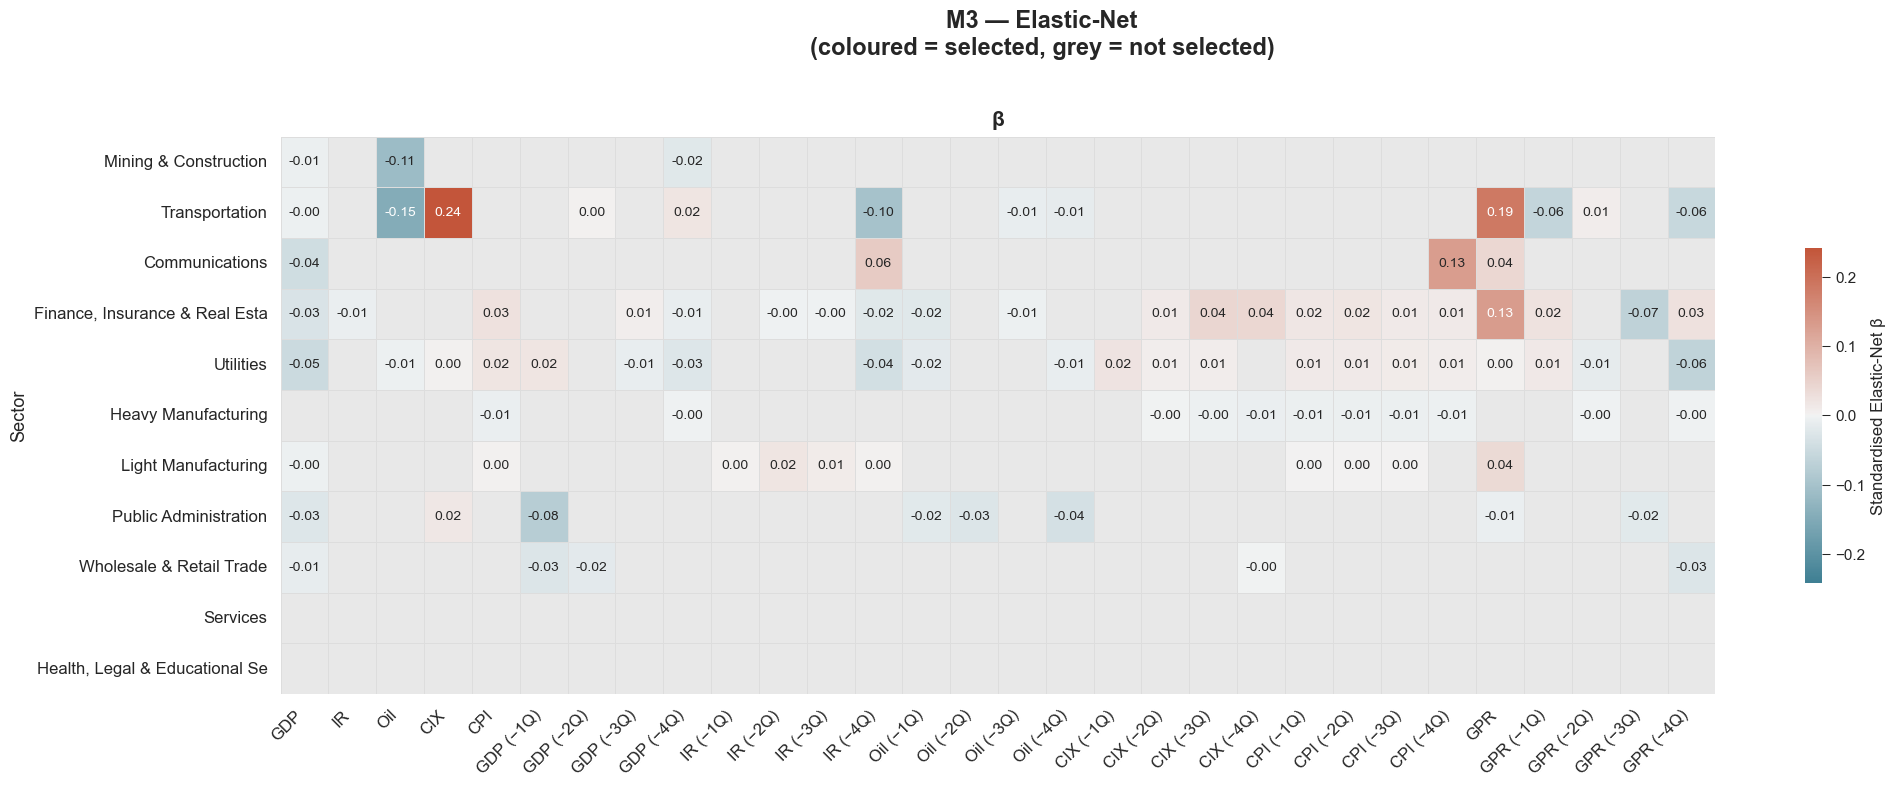

In [35]:
# ── Thesis heatmaps: M1 full-lag OLS, M2 cumulative OLS, M3 Elastic-Net ─────
# Same plotting function for all three models. Grey = insignificant / not selected.

import importlib
importlib.reload(plots)

_pd_h = config.PD_MATURITY_COLS[0]

plots.plot_lasso_beta_heatmap(
    df_sensitivities,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    pd_horizon=_pd_h,
    mode='ols',
    title='M1 — Full-Lag OLS\n(coloured = significant, grey = insignificant)',
)

plots.plot_lasso_beta_heatmap(
    df_sensitivities,
    macro_cols=config.MACRO_COLS,
    gpr_cols=config.GPR_COLS,
    pd_horizon=_pd_h,
    title='M2 — Cumulative OLS\n(coloured = significant, grey = insignificant)',
)

plots.plot_lasso_beta_heatmap(
    df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    pd_horizon=_pd_h,
    title='M3 — Elastic-Net\n(coloured = selected, grey = not selected)',
)